# 1 de cada 2.078. ¿Por qué una variante de cáncer de pulmón se concentra en los Apalaches?

En el mundo, 1 de cada 15.850 personas lleva una variante heredada del gen EGFR llamada T790M. En EE. UU., 1 de cada 8.920. En los Apalaches del sur, 1 de cada 2.078 — 7,6 veces la frecuencia global. Quien la lleva tiene 25 veces más probabilidades de cáncer de pulmón. Y la asociación es más fuerte en quienes nunca han fumado.

:::{image} figuras/pixabot.png
:alt: Pixabot mascot
:width: 80px
:align: center
:figclass: pixabot-mascot
:::

**Paper:** LoPiccolo et al. (2026). *Germline EGFR T790M mutation and lung cancer risk*. **Science**.
DOI: [10.1126/science.aec0473](https://doi.org/10.1126/science.aec0473) · paywall (tablas suplementarias abiertas)

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ciencia-a-Mordiscos/lab/blob/main/papers/2026-09-18-egfr-t790m-cancer-pulmon-apalaches/notebook.ipynb)

**Video:** pendiente

## De qué va esto

EGFR es un gen que fabrica un receptor de crecimiento celular. Muchos cánceres de pulmón lo tienen mutado *en el tumor*; lo raro es nacer ya con una de esas mutaciones en todas las células del cuerpo — una variante *germinal*, heredada de madre o padre. La T790M es una de ellas, y hasta ahora nadie sabía bien cuánto riesgo conlleva ni por qué aparece donde aparece.

Un equipo de Dana-Farber, Vanderbilt y 23andMe cruzó tres cosas: (1) los genotipos y diagnósticos de 3,37 millones de participantes de 23andMe, (2) 41 familias del estudio INHERIT — 1.145 personas en los pedigríes, reclutadas porque alguien en la familia tenía cáncer de pulmón y la variante — y (3) un mapa de parentesco genético (*identidad por descendencia*, IBD): cuántos centimorganes de genoma comparte, en promedio, un residente de cada región del mundo con los portadores de T790M.

Lo que tenemos en abierto: las tablas suplementarias con los *odds ratios*, los conteos por grupo, el pedigrí completo de las 41 familias y las 500 regiones y 500 condados con más IBD. El código de los autores está en GitHub y de ahí sacamos cómo recodificar el genotipo. Es un estudio observacional: aquí hablamos de asociación, no de causa. Veamos.

In [1]:
# ══════════════════════════════════════════════════════════════
# Configuración — modifica estos valores para explorar
# ══════════════════════════════════════════════════════════════
GRUPO_ANCESTRIA = 'All'      # 'All', 'Southern Colonial', 'British Isles', 'African American', ...
TOP_N_REGIONES = 25          # regiones del mundo a mostrar en el ranking de IBD
# Nueve estados del sureste apalache — nuestra definicion, no la del paper
SURESTE_APALACHE = ['Tennessee', 'Kentucky', 'West Virginia', 'Virginia', 'North Carolina',
                    'Georgia', 'Alabama', 'Mississippi', 'South Carolina']
FUENTE = 'Fuente: LoPiccolo et al. (2026), Science | Datos: tablas suplementarias S2, S5b, S7b, S13 y S14'
COLOR_DATOS = '#2563EB'
COLOR_ALERTA = '#DC2626'
COLOR_SECUNDARIO = '#059669'
COLOR_REFERENCIA = '#D97706'
COLOR_CORRELACION = '#7C3AED'
COLOR_CONTEXTO = '#BBBBBB'

import os, urllib.request, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
warnings.filterwarnings('ignore')

BASE = 'https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main'
PAPER = f'{BASE}/papers/2026-09-18-egfr-t790m-cancer-pulmon-apalaches'

# Estilo CaM (local -> fallback GitHub)
style_file = '../../cam.mplstyle'
if not os.path.exists(style_file):
    style_file = '/tmp/cam.mplstyle'
    if not os.path.exists(style_file):
        urllib.request.urlretrieve(f'{BASE}/cam.mplstyle', style_file)
plt.style.use(style_file)

# Datos (descarga automatica si no estan en local)
os.makedirs('datos', exist_ok=True)
os.makedirs('figuras', exist_ok=True)
ARCHIVOS = ['modelos_asociacion.csv', 'conteos_por_grupo.csv', 'pedigris_inherit.csv',
            'ibd_estados.csv', 'ibd_condados_eeuu.csv']
for f in ARCHIVOS:
    if not os.path.exists(f'datos/{f}'):
        urllib.request.urlretrieve(f'{PAPER}/datos/{f}', f'datos/{f}')

mod = pd.read_csv('datos/modelos_asociacion.csv')    # odds ratios del paper (Tables S2 y S7b)
cnt = pd.read_csv('datos/conteos_por_grupo.csv')     # casos/controles por grupo (Table S7b)
ped = pd.read_csv('datos/pedigris_inherit.csv')      # 41 pedigries INHERIT (Table S5b)
ibd = pd.read_csv('datos/ibd_estados.csv')           # IBD medio por region del mundo (Table S13)
con = pd.read_csv('datos/ibd_condados_eeuu.csv')     # IBD medio por condado de EE. UU. (Table S14)

def es(x, dec=0):
    # formato espanol: 15.850 / 3,78
    s = f'{x:,.{dec}f}'
    return s.replace(',', 'X').replace('.', ',').replace('X', '.')

def sci(p):
    # p-value legible: 0,002 / 1,9×10⁻²⁴
    if p >= 0.001:
        return es(p, 3)
    exp = int(np.floor(np.log10(p)))
    mant = p / 10**exp
    sup = str(exp).translate(str.maketrans('-0123456789', '⁻⁰¹²³⁴⁵⁶⁷⁸⁹'))
    return f'{es(mant, 1)}×10{sup}'

# Recodeo del genotipo (segun el notebook R de los autores):
# portador_t790m = 1 portador, 0 NO portador, NaN sin genotipar
geno = ped.dropna(subset=['portador_t790m']).copy()
geno['portador_t790m'] = geno['portador_t790m'].astype(int)

print(f'Modelos de asociación: {len(mod)} filas ({mod.regimen.nunique()} regímenes)')
print(f'Conteos por grupo: {es(cnt.total.sum())} participantes con haplotipo definido')
print(f'Pedigríes INHERIT: {es(len(ped))} personas en {ped.familia_id.nunique()} familias, '
      f'{es(ped.caso_cancer_pulmon.sum())} con cáncer de pulmón, {len(geno)} genotipadas')
print(f'IBD por región: {len(ibd)} filas ({ibd.grupo_ancestria.nunique()} grupos de ancestría), '
      f'{(ibd.grupo_ancestria == "All").sum()} regiones en {ibd[ibd.grupo_ancestria == "All"].pais.nunique()} países')
print(f'IBD por condado: {(con.grupo_ancestria == "All").sum()} condados en '
      f'{con[con.grupo_ancestria == "All"].estado.nunique()} estados')

Modelos de asociación: 8 filas (2 regímenes)
Conteos por grupo: 2.496.375 participantes con haplotipo definido
Pedigríes INHERIT: 1.145 personas en 41 familias, 151 con cáncer de pulmón, 245 genotipadas
IBD por región: 3444 filas (7 grupos de ancestría), 500 regiones en 83 países
IBD por condado: 500 condados en 19 estados


## Aquí está.

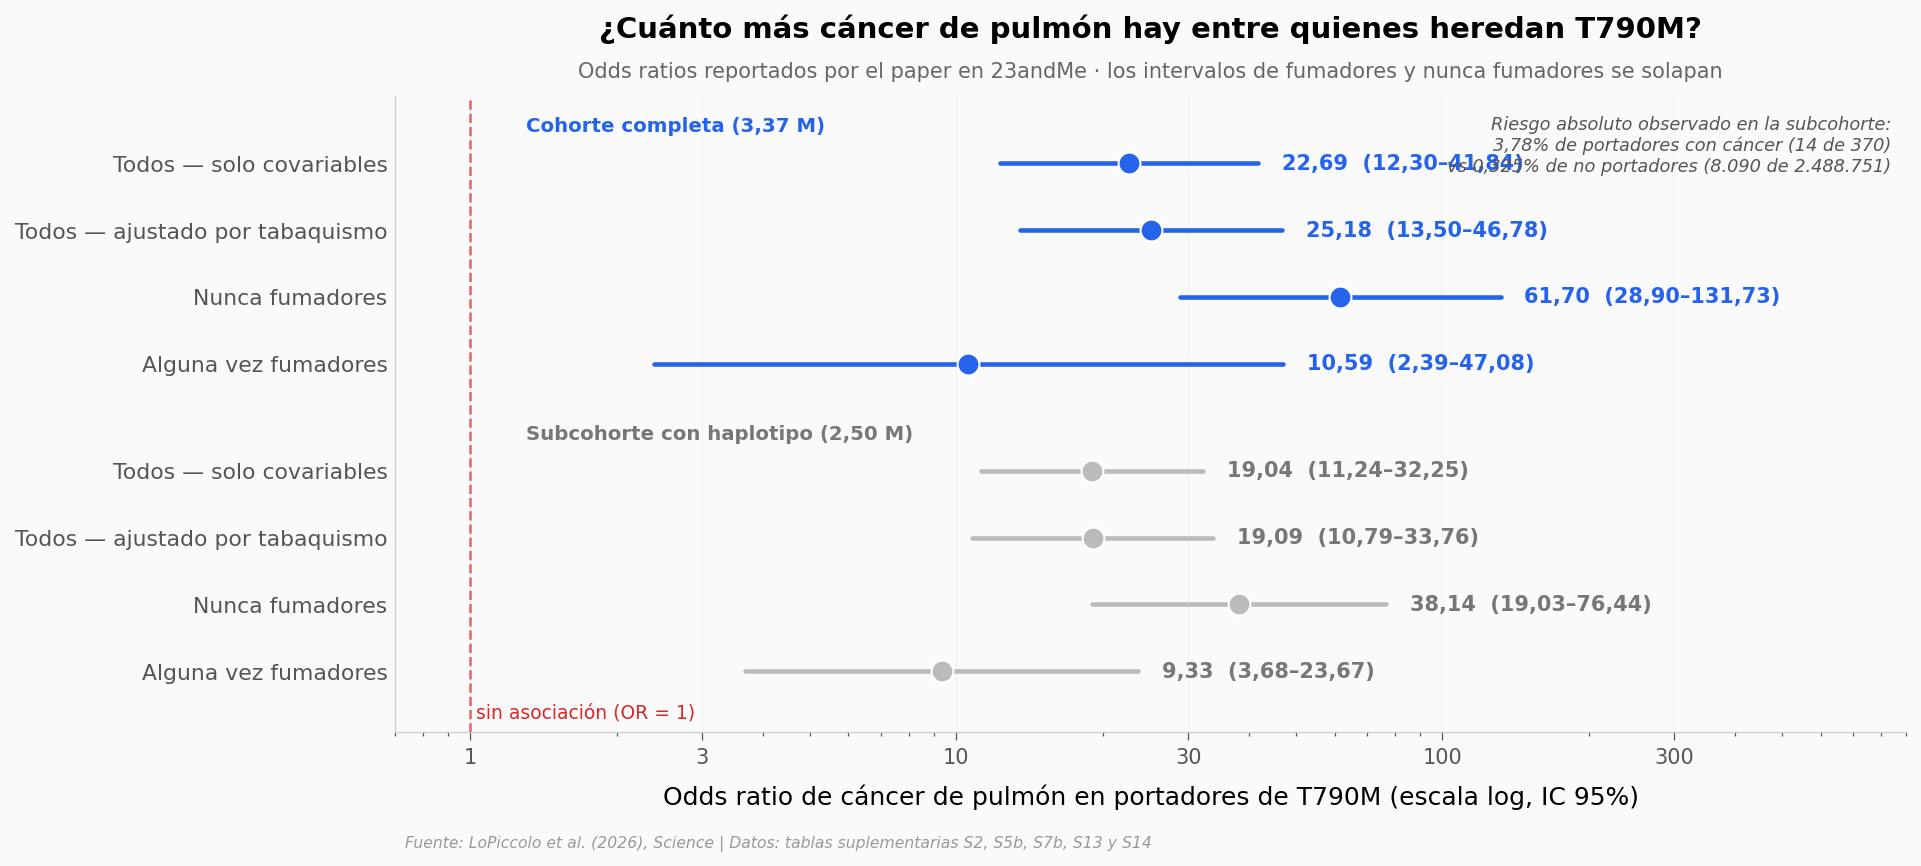

Riesgo relativo crudo desde los conteos: 11,6x · OR crudo: 12,1 (vs 19,04 ajustado por covariables en la misma subcohorte)
Nunca fumadores / alguna vez fumadores: 5,8x — pero el IC de fumadores (2,39–47,08) se solapa parcialmente con el de nunca fumadores (28,9–131,7)


In [2]:
fig, ax = plt.subplots(figsize=(13, 5.5))

ETIQ_REG = {'cohorte_completa_23andMe': 'Cohorte completa (3,37 M)',
            'subcohorte_haplotipo': 'Subcohorte con haplotipo (2,50 M)'}
COL_REG = {'cohorte_completa_23andMe': COLOR_DATOS, 'subcohorte_haplotipo': COLOR_CONTEXTO}
ETIQ_FILA = {('Solo covariables', 'Todos'): 'Todos — solo covariables',
             ('Modelo con tabaquismo', 'Todos'): 'Todos — ajustado por tabaquismo',
             ('Interaccion tabaquismo', 'Nunca fumadores'): 'Nunca fumadores',
             ('Interaccion tabaquismo', 'Alguna vez fumadores'): 'Alguna vez fumadores'}

# Orden: cohorte completa arriba, subcohorte abajo; dentro de cada una el orden de la tabla
filas = []
for reg in ['cohorte_completa_23andMe', 'subcohorte_haplotipo']:
    sub = mod[mod.regimen == reg]
    for _, r in sub.iterrows():
        filas.append((reg, ETIQ_FILA[(r.modelo, r.estrato)], r.odds_ratio, r.ic95_bajo, r.ic95_alto))

ys = np.arange(len(filas))[::-1].astype(float)
ys[4:] -= 0.6   # hueco entre regimenes
for y, (reg, etiq, o, lo, hi) in zip(ys, filas):
    c = COL_REG[reg]
    ax.plot([lo, hi], [y, y], color=c, lw=2.2, solid_capstyle='round', zorder=4)
    ax.scatter([o], [y], color=c, s=110, edgecolors='white', linewidths=1, zorder=5)
    ax.text(hi * 1.12, y, f'{es(o, 2)}  ({es(lo, 2)}–{es(hi, 2)})', va='center', fontsize=10,
            color=c if reg == 'cohorte_completa_23andMe' else '#777777', fontweight='bold')

ax.set_yticks(ys)
ax.set_yticklabels([f[1] for f in filas], fontsize=10.5)
ax.axvline(1, color=COLOR_ALERTA, lw=1.2, ls='--', alpha=0.7)
ax.text(1.03, ys[-1] - 0.75, 'sin asociación (OR = 1)', color=COLOR_ALERTA, fontsize=9, va='bottom')
ax.set_xscale('log')
ax.set_xlim(0.7, 900)
ax.set_xticks([1, 3, 10, 30, 100, 300])
ax.set_xticklabels(['1', '3', '10', '30', '100', '300'])
ax.set_xlabel('Odds ratio de cáncer de pulmón en portadores de T790M (escala log, IC 95%)')
ax.grid(axis='y', visible=False)
ax.grid(axis='x', alpha=0.3)

# Etiquetas de regimen (inline, sin caja de leyenda)
ax.text(1.3, ys[0] + 0.55, ETIQ_REG['cohorte_completa_23andMe'], color=COLOR_DATOS,
        fontsize=9.5, fontweight='bold', va='center')
ax.text(1.3, ys[4] + 0.55, ETIQ_REG['subcohorte_haplotipo'], color='#777777',
        fontsize=9.5, fontweight='bold', va='center')
ax.set_ylim(ys[-1] - 0.9, ys[0] + 1.0)

# Riesgo absoluto, para que el OR no suene a sentencia
port = cnt[cnt.grupo.str.startswith('Portador')].iloc[0]
ref = cnt[cnt.grupo == 'No portador, sin haplotipo'].iloc[0]
ax.text(0.99, 0.97,
        f'Riesgo absoluto observado en la subcohorte:\n'
        f'{es(port.tasa_cancer_pct, 2)}% de portadores con cáncer ({port.casos_cancer_pulmon} de {es(port.total)})\n'
        f'vs {es(ref.tasa_cancer_pct, 3)}% de no portadores ({es(ref.casos_cancer_pulmon)} de {es(ref.total)})',
        transform=ax.transAxes, fontsize=8.5, color='#555555', ha='right', va='top', style='italic')

ax.set_title('¿Cuánto más cáncer de pulmón hay entre quienes heredan T790M?', fontsize=14,
             fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Odds ratios reportados por el paper en 23andMe · los intervalos de fumadores y nunca fumadores se solapan',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/hero_odds_ratios.png', dpi=200, bbox_inches='tight')
plt.show()

rr_crudo = port.tasa_cancer_pct / ref.tasa_cancer_pct
or_crudo = (port.casos_cancer_pulmon / port.controles_sin_cancer) / (ref.casos_cancer_pulmon / ref.controles_sin_cancer)
nf = mod[(mod.regimen == 'cohorte_completa_23andMe') & (mod.estrato == 'Nunca fumadores')].iloc[0]
af = mod[(mod.regimen == 'cohorte_completa_23andMe') & (mod.estrato == 'Alguna vez fumadores')].iloc[0]
print(f'Riesgo relativo crudo desde los conteos: {es(rr_crudo, 1)}x · OR crudo: {es(or_crudo, 1)} '
      f'(vs {es(mod.iloc[4].odds_ratio, 2)} ajustado por covariables en la misma subcohorte)')
print(f'Nunca fumadores / alguna vez fumadores: {es(nf.odds_ratio / af.odds_ratio, 1)}x '
      f'— pero el IC de fumadores ({es(af.ic95_bajo, 2)}–{es(af.ic95_alto, 2)}) se solapa parcialmente con el de nunca fumadores ({es(nf.ic95_bajo, 1)}–{es(nf.ic95_alto, 1)})')

Lo primero: en la cohorte completa ajustada por tabaquismo, el OR es 25,18 (IC 95% 13,50–46,78). Los portadores de T790M tienen unas 25 veces más probabilidades de cáncer de pulmón que el resto. Ningún intervalo se acerca al 1, ni en la cohorte completa ni en la subcohorte de 2,50 millones donde el haplotipo — el tramo de cromosoma que rodea a la variante y confirma que todos los portadores heredaron la misma copia — está bien definido.

Lo segundo, y esto importa para no asustar a nadie: un OR de 25 no significa "25% de riesgo". En la subcohorte con conteos abiertos, el 3,784% de los portadores tenía diagnóstico de cáncer de pulmón (14 de 370) frente al 0,325% de los no portadores (8.090 de 2.488.751). Es un riesgo 11,6 veces mayor en crudo, sin ajustar por edad ni sexo — por eso queda por debajo del 19,04 ajustado del paper para esa misma subcohorte. Mismo fenómeno, con y sin covariables.

Lo tercero es el dato que da título al abstract: en nunca fumadores el OR sube a 61,70; en quienes fumaron alguna vez baja a 10,59. El cociente es 5,8, pero mira los intervalos — el de nunca fumadores va de 28,90 a 131,73 y el de fumadores de 2,39 a 47,08. Se solapan en buena parte. Lo que sí sostienen los datos es que la asociación es *varias veces* mayor en no fumadores; el "5,8" exacto no.

Un detalle que suele perderse: el paper dice que esta variante no aumentó el riesgo de otros 17 tipos de cáncer. Es específica de pulmón.

## Dentro de las familias

Los 3,37 millones de 23andMe dan potencia estadística, pero comparan desconocidos. Las 41 familias del estudio INHERIT permiten otra cosa: comparar hermanos que crecieron en la misma casa, unos con la variante y otros sin ella. Si el cáncer sigue a la variante *dentro* de cada familia, el argumento gana peso.

Un aviso antes de mirar: estas familias se reclutaron porque alguien tenía cáncer de pulmón *y* la variante. Los porcentajes crudos están inflados por construcción. Los tests entre hermanos y de transmisión padre-hijo existen justamente para esquivar ese sesgo.

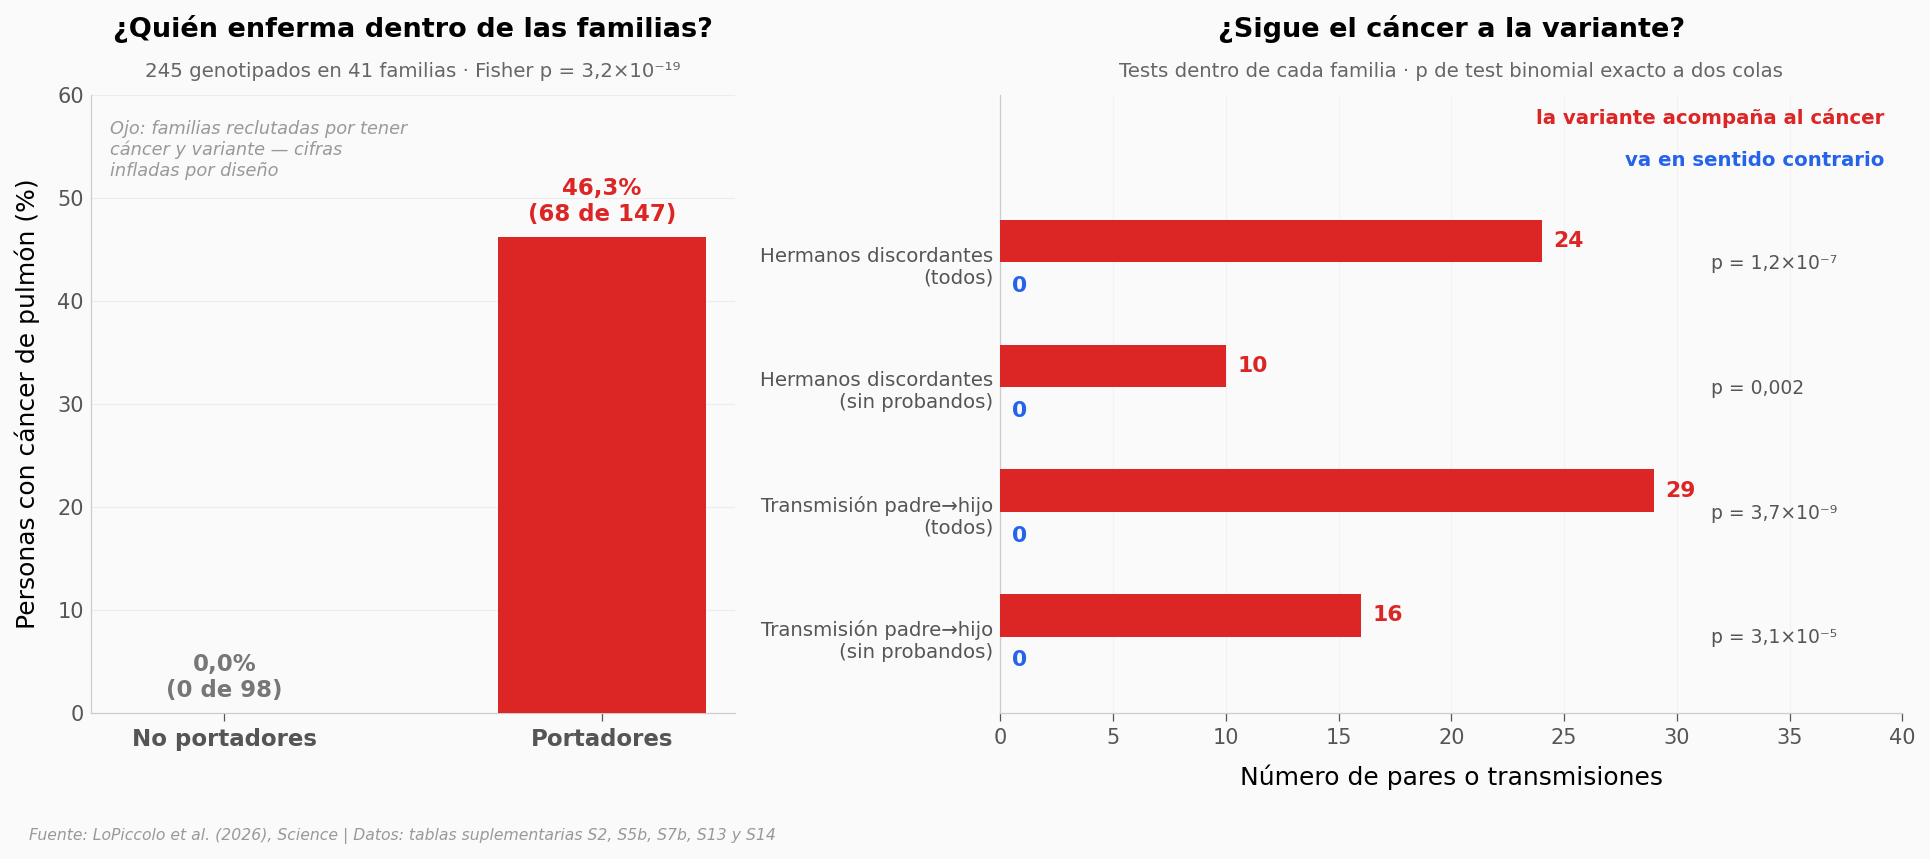

2×2: 68 de 147 portadores con cáncer (46,3%) vs 0 de 98 no portadores (0,0%), Fisher p = 3,2×10⁻¹⁹
Casos de cáncer sin genotipar: 83 de 151
McNemar: 15 hermandades / 45 hermanos → B = 24, C = 0, p = 1,2×10⁻⁷
McNemar sin probandos: 6 hermandades / 19 hermanos → B = 10, C = 0, p = 0,002
TDT: transmitida 29 de 29 veces, p = 3,7×10⁻⁹ — pero 13 de esos 29 hijos afectados son probandos
TDT sin probandos: transmitida 16 de 16 veces, p = 3,1×10⁻⁵


In [3]:
# ── 2x2 entre genotipados ──
tab = pd.crosstab(geno.portador_t790m, geno.caso_cancer_pulmon)   # filas: 0/1 portador, cols: 0/1 cancer
n_port, n_noport = tab.loc[1].sum(), tab.loc[0].sum()
c_port, c_noport = tab.loc[1, 1], tab.loc[0, 1]
pct_port, pct_noport = 100 * c_port / n_port, 100 * c_noport / n_noport
_, p_fisher = stats.fisher_exact([[c_port, n_port - c_port], [c_noport, n_noport - c_noport]])

# ── McNemar entre hermanos (replica del notebook R de los autores) ──
# Hermandad = misma pareja de padres, con AMBOS padres en el pedigri, >=1 hermano con cancer
# y >=1 sin cancer genotipados, y genotipos discordantes dentro de la hermandad.
# B = pares (afectado portador, sano no portador); C = pares (afectado no portador, sano portador)
def mcnemar(df):
    B = C = 0; n_herm = n_sibs = 0
    for _, grp in df.groupby('familia_nuclear'):
        if grp.padre_id.iloc[0] == 0 or grp.madre_id.iloc[0] == 0 or grp.portador_t790m.nunique() < 2:
            continue
        aff, san = grp[grp.caso_cancer_pulmon == 1], grp[grp.caso_cancer_pulmon == 0]
        if len(aff) == 0 or len(san) == 0:
            continue
        n_herm += 1; n_sibs += len(grp)
        for _, a in aff.iterrows():
            for _, s in san.iterrows():
                B += int(a.portador_t790m == 1 and s.portador_t790m == 0)
                C += int(a.portador_t790m == 0 and s.portador_t790m == 1)
    return B, C, n_herm, n_sibs, stats.binomtest(B, B + C, 0.5).pvalue

# ── TDT: transmision de padres portadores genotipados a hijos con cancer ──
gmap = ped.set_index(['familia_id', 'individuo_id']).portador_t790m
def tdt(df):
    T = NT = 0
    for _, h in df[df.caso_cancer_pulmon == 1].iterrows():
        for pid in (h.padre_id, h.madre_id):
            if gmap.get((h.familia_id, pid)) == 1:      # progenitor portador (heterocigoto)
                T += int(h.portador_t790m == 1)
                NT += int(h.portador_t790m == 0)
    return T, NT, stats.binomtest(T, T + NT, 0.5).pvalue

B, C, n_herm, n_sibs, p_mc = mcnemar(geno)
B2, C2, n_herm2, n_sibs2, p_mc2 = mcnemar(geno[geno.es_probando == 0])
T, NT, p_tdt = tdt(geno)
T2, NT2, p_tdt2 = tdt(geno[geno.es_probando == 0])
n_prob_tdt = int(geno[(geno.caso_cancer_pulmon == 1) & (geno.es_probando == 1)].apply(
    lambda h: any(gmap.get((h.familia_id, pid)) == 1 for pid in (h.padre_id, h.madre_id)), axis=1).sum())

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5.5), gridspec_kw={'width_ratios': [1, 1.4]})

# Panel izquierdo: % con cancer por genotipo
xs = [0, 1]
vals = [pct_noport, pct_port]
cols = [COLOR_CONTEXTO, COLOR_ALERTA]
ax1.bar(xs, vals, color=cols, width=0.55, zorder=4)
for x, v, n, c in zip(xs, vals, [n_noport, n_port], [c_noport, c_port]):
    ax1.text(x, v + 1.5, f'{es(v, 1)}%\n({c} de {n})', ha='center', fontsize=11, fontweight='bold',
             color=COLOR_ALERTA if v > 0 else '#777777')
ax1.set_xticks(xs)
ax1.set_xticklabels(['No portadores', 'Portadores'], fontsize=11, fontweight='bold')
ax1.set_ylim(0, 60)
ax1.set_ylabel('Personas con cáncer de pulmón (%)')
ax1.set_title('¿Quién enferma dentro de las familias?', fontsize=13, fontweight='bold', pad=28)
ax1.text(0.5, 1.03, f'{len(geno)} genotipados en {ped.familia_id.nunique()} familias · Fisher p = {sci(p_fisher)}',
         transform=ax1.transAxes, fontsize=9.5, color='#666666', ha='center')
ax1.text(0.03, 0.96, 'Ojo: familias reclutadas por tener\ncáncer y variante — cifras\ninfladas por diseño',
         transform=ax1.transAxes, fontsize=8.5, color='#999999', ha='left', va='top', style='italic')

# Panel derecho: tests que esquivan el sesgo de reclutamiento
tests = [('Hermanos discordantes\n(todos)', B, C, p_mc),
         ('Hermanos discordantes\n(sin probandos)', B2, C2, p_mc2),
         ('Transmisión padre→hijo\n(todos)', T, NT, p_tdt),
         ('Transmisión padre→hijo\n(sin probandos)', T2, NT2, p_tdt2)]
ys = np.arange(len(tests))[::-1]
for y, (etiq, a, b, p) in zip(ys, tests):
    ax2.barh(y + 0.18, a, height=0.34, color=COLOR_ALERTA, zorder=4)
    ax2.barh(y - 0.18, b, height=0.34, color=COLOR_DATOS, zorder=4)
    ax2.text(a + 0.5, y + 0.18, f'{a}', va='center', fontsize=10.5, fontweight='bold', color=COLOR_ALERTA)
    ax2.text(b + 0.5, y - 0.18, f'{b}', va='center', fontsize=10.5, fontweight='bold', color=COLOR_DATOS)
    ax2.text(31.5, y, f'p = {sci(p)}', va='center', fontsize=9, color='#555555')
ax2.set_yticks(ys)
ax2.set_yticklabels([t[0] for t in tests], fontsize=9.5)
ax2.set_xlim(0, 40)
ax2.set_ylim(-0.6, len(tests) - 1 + 1.35)   # banda libre arriba para las etiquetas inline
ax2.set_xlabel('Número de pares o transmisiones')
ax2.grid(axis='y', visible=False)
ax2.grid(axis='x', alpha=0.3)
ax2.text(0.98, 0.98, 'la variante acompaña al cáncer', transform=ax2.transAxes, ha='right', va='top',
         fontsize=9.5, fontweight='bold', color=COLOR_ALERTA)
ax2.text(0.98, 0.91, 'va en sentido contrario', transform=ax2.transAxes, ha='right', va='top',
         fontsize=9.5, fontweight='bold', color=COLOR_DATOS)
ax2.set_title('¿Sigue el cáncer a la variante?', fontsize=13, fontweight='bold', pad=28)
ax2.text(0.5, 1.03, 'Tests dentro de cada familia · p de test binomial exacto a dos colas',
         transform=ax2.transAxes, fontsize=9.5, color='#666666', ha='center')

plt.tight_layout()
fig.text(0.02, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/familias_inherit.png', dpi=200, bbox_inches='tight')
plt.show()

print(f'2×2: {c_port} de {n_port} portadores con cáncer ({es(pct_port, 1)}%) vs {c_noport} de {n_noport} no portadores ({es(pct_noport, 1)}%), Fisher p = {sci(p_fisher)}')
print(f'Casos de cáncer sin genotipar: {int(ped[ped.portador_t790m.isna()].caso_cancer_pulmon.sum())} de {int(ped.caso_cancer_pulmon.sum())}')
print(f'McNemar: {n_herm} hermandades / {n_sibs} hermanos → B = {B}, C = {C}, p = {sci(p_mc)}')
print(f'McNemar sin probandos: {n_herm2} hermandades / {n_sibs2} hermanos → B = {B2}, C = {C2}, p = {sci(p_mc2)}')
print(f'TDT: transmitida {T} de {T + NT} veces, p = {sci(p_tdt)} — pero {n_prob_tdt} de esos {T + NT} hijos afectados son probandos')
print(f'TDT sin probandos: transmitida {T2} de {T2 + NT2} veces, p = {sci(p_tdt2)}')

Dentro de las familias el patrón es limpio: 68 de 147 portadores genotipados tenían cáncer de pulmón y 0 de 98 no portadores. Entre hermanos criados juntos, en 24 pares la variante estaba en el hermano enfermo y no en el sano; en 0 pares al revés. Y cada vez que un padre portador tuvo un hijo con cáncer, ese hijo había heredado la variante: 29 de 29.

Ese 29 de 29 tiene truco. El material suplementario dice que el test se hace en hijos afectados *que no sean probandos* — pero el código publicado no los filtra, y 13 de esos 29 hijos son los probandos por los que se reclutó a la familia. Quitándolos quedan 16 de 16 (p = 3,05×10⁻⁵). Misma dirección, cuatro órdenes de magnitud menos de certeza. Lo reportamos ambos.

Queda la pregunta del título: ¿por qué los Apalaches? El equipo midió cuánto genoma comparte, en promedio, un residente de cada región del mundo con los portadores de T790M. Si la variante nació de un solo antepasado y se multiplicó en un sitio, ese sitio debería iluminarse.

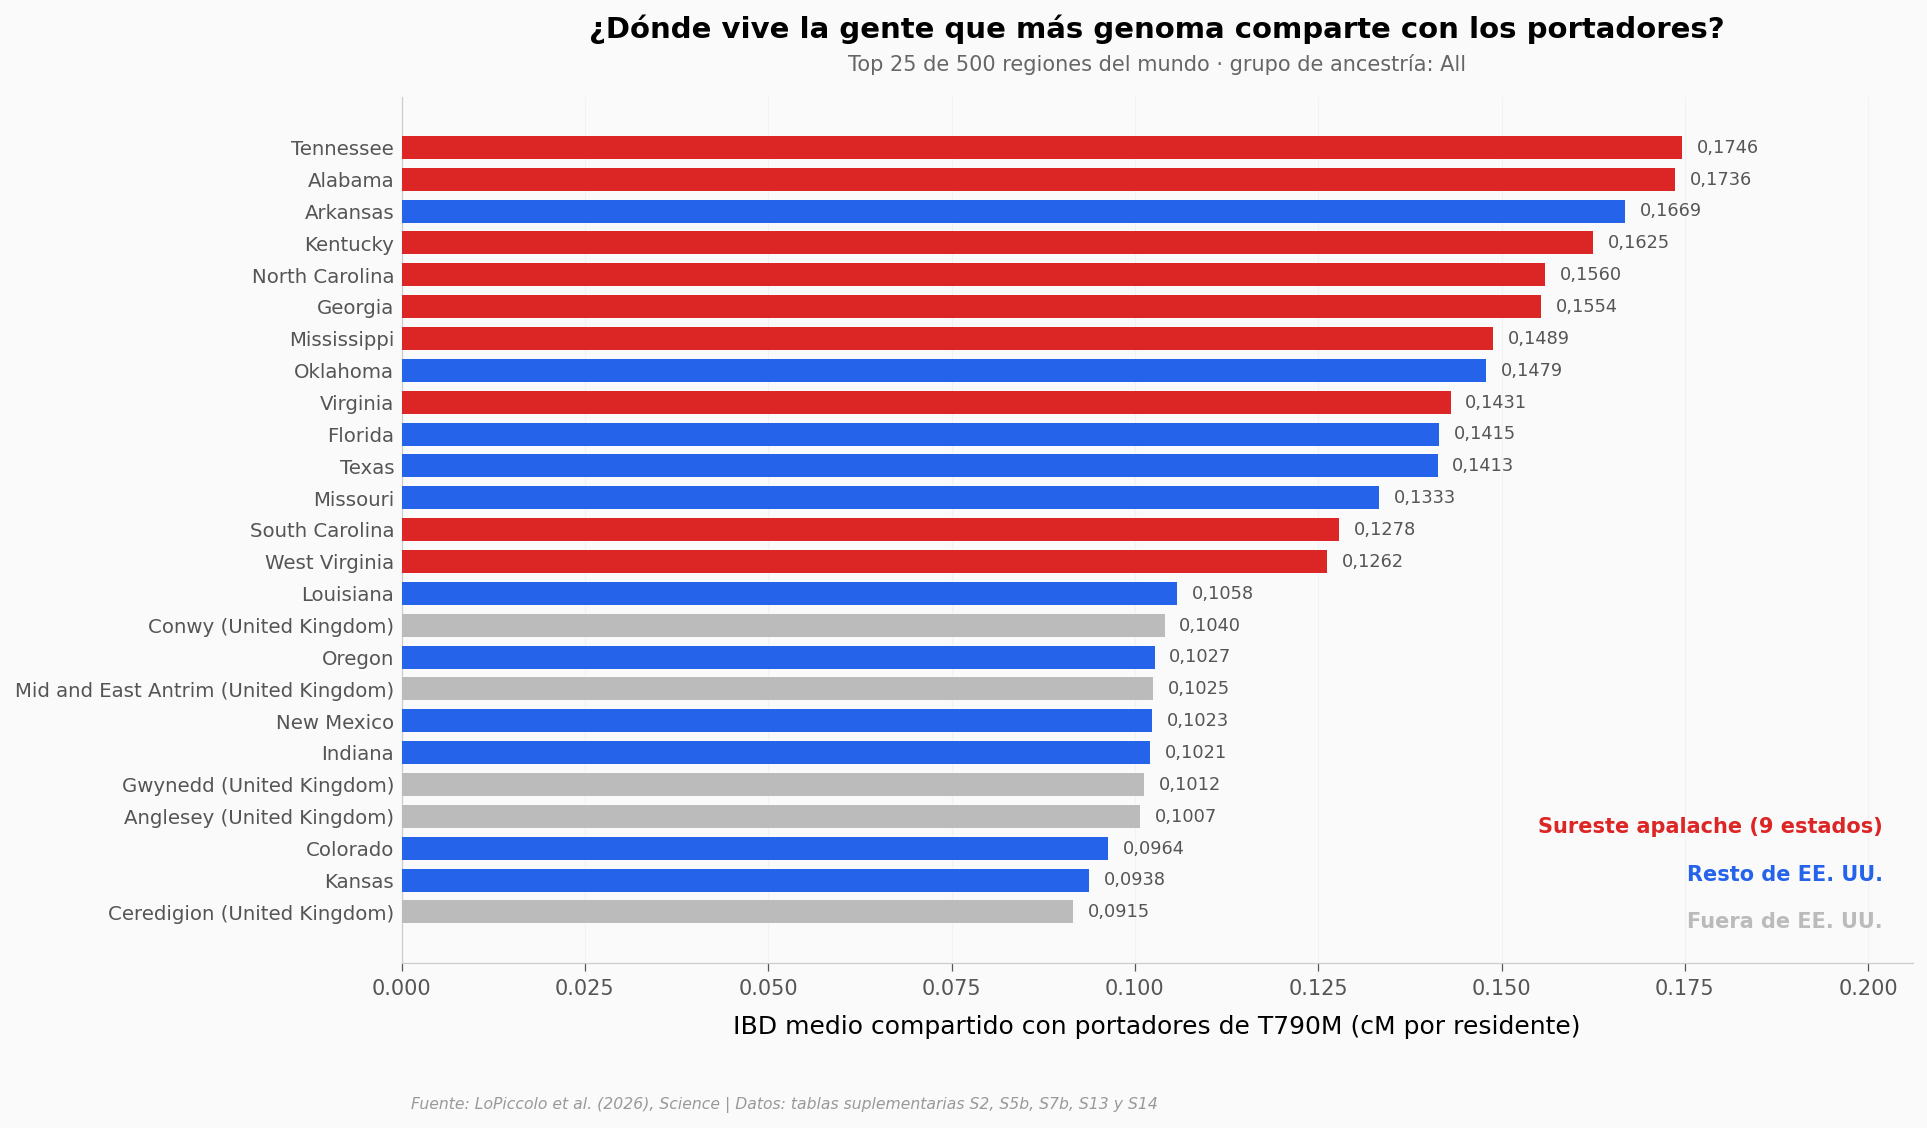

Regiones de EE. UU.: 51, mediana 0,0778 cM (IQR 0,0572–0,1270)
Fuera de EE. UU.: 449 regiones en 82 países, mediana 0,0373 cM (IQR 0,0288–0,0511) → 2,1x, Mann-Whitney p = 5,9×10⁻²⁰, r biserial = 0,78
Sureste apalache (n=9): mediana 0,1554 vs resto de EE. UU. (n=42): 0,0701 → 2,2x, p = 2,0×10⁻⁵, r biserial = 0,92
Mejor región fuera de EE. UU.: Conwy (Reino Unido) con 0,1040 cM; Tennessee la supera por 1,7x


In [4]:
reg = ibd[ibd.grupo_ancestria == GRUPO_ANCESTRIA].copy()
reg['zona'] = np.where(reg.pais != 'United States', 'fuera',
              np.where(reg.estado.isin(SURESTE_APALACHE), 'sureste', 'resto_eeuu'))
COL_ZONA = {'sureste': COLOR_ALERTA, 'resto_eeuu': COLOR_DATOS, 'fuera': COLOR_CONTEXTO}
ETIQ_ZONA = {'sureste': 'Sureste apalache (9 estados)', 'resto_eeuu': 'Resto de EE. UU.', 'fuera': 'Fuera de EE. UU.'}

top = reg.sort_values('ibd_medio_cm', ascending=False).head(TOP_N_REGIONES).reset_index(drop=True)
top['nombre'] = np.where(top.pais == 'United States', top.estado, top.estado + ' (' + top.pais + ')')

fig, ax = plt.subplots(figsize=(13, 7.5))
ys = np.arange(len(top))[::-1]
ax.barh(ys, top.ibd_medio_cm, color=[COL_ZONA[z] for z in top.zona], height=0.72, zorder=4)
for y, v in zip(ys, top.ibd_medio_cm):
    ax.text(v + 0.002, y, es(v, 4), va='center', fontsize=8.5, color='#555555')
ax.set_yticks(ys)
ax.set_yticklabels(top.nombre, fontsize=9.5)
ax.set_xlabel('IBD medio compartido con portadores de T790M (cM por residente)')
ax.grid(axis='y', visible=False)
ax.grid(axis='x', alpha=0.3)
ax.set_xlim(0, top.ibd_medio_cm.max() * 1.18)
# etiquetas inline de zona
for i, z in enumerate(['sureste', 'resto_eeuu', 'fuera']):
    ax.text(0.98, 0.04 + 0.055 * (2 - i), ETIQ_ZONA[z], transform=ax.transAxes, ha='right',
            fontsize=10, fontweight='bold', color=COL_ZONA[z])
ax.set_title(f'¿Dónde vive la gente que más genoma comparte con los portadores?', fontsize=14,
             fontweight='bold', pad=28)
ax.text(0.5, 1.03, f'Top {TOP_N_REGIONES} de {len(reg)} regiones del mundo · grupo de ancestría: {GRUPO_ANCESTRIA}',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
fig.text(0.13, -0.02, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/ranking_ibd_regiones.png', dpi=200, bbox_inches='tight')
plt.show()

us, fuera = reg[reg.pais == 'United States'], reg[reg.pais != 'United States']
sur, resto = us[us.estado.isin(SURESTE_APALACHE)], us[~us.estado.isin(SURESTE_APALACHE)]
u1, p_mw = stats.mannwhitneyu(us.ibd_medio_cm, fuera.ibd_medio_cm)
u2, p_mw2 = stats.mannwhitneyu(sur.ibd_medio_cm, resto.ibd_medio_cm)
# tamano del efecto para Mann-Whitney: r biserial por rangos = 2U/(n1*n2) - 1 (datos no normales, skew > 2)
rb1 = abs(2 * u1 / (len(us) * len(fuera)) - 1)
rb2 = abs(2 * u2 / (len(sur) * len(resto)) - 1)
uk = fuera[fuera.pais == 'United Kingdom'].sort_values('ibd_medio_cm', ascending=False)
print(f'Regiones de EE. UU.: {len(us)}, mediana {es(us.ibd_medio_cm.median(), 4)} cM (IQR {es(us.ibd_medio_cm.quantile(.25), 4)}–{es(us.ibd_medio_cm.quantile(.75), 4)})')
print(f'Fuera de EE. UU.: {len(fuera)} regiones en {fuera.pais.nunique()} países, mediana {es(fuera.ibd_medio_cm.median(), 4)} cM '
      f'(IQR {es(fuera.ibd_medio_cm.quantile(.25), 4)}–{es(fuera.ibd_medio_cm.quantile(.75), 4)}) → {es(us.ibd_medio_cm.median() / fuera.ibd_medio_cm.median(), 1)}x, Mann-Whitney p = {sci(p_mw)}, r biserial = {es(rb1, 2)}')
print(f'Sureste apalache (n={len(sur)}): mediana {es(sur.ibd_medio_cm.median(), 4)} vs resto de EE. UU. (n={len(resto)}): {es(resto.ibd_medio_cm.median(), 4)} → {es(sur.ibd_medio_cm.median() / resto.ibd_medio_cm.median(), 1)}x, p = {sci(p_mw2)}, r biserial = {es(rb2, 2)}')
print(f'Mejor región fuera de EE. UU.: {uk.iloc[0].estado} (Reino Unido) con {es(uk.iloc[0].ibd_medio_cm, 4)} cM; '
      f'Tennessee la supera por {es(us.ibd_medio_cm.max() / uk.iloc[0].ibd_medio_cm, 1)}x')

Las 25 primeras posiciones del mundo son estados de EE. UU. menos una, y las 9 del sureste apalache ocupan la cabeza: Tennessee, Alabama, Kentucky, Carolina del Norte, Georgia. La primera región no estadounidense es Conwy, en Gales, con 0,1040 cM — Tennessee la supera por 1,7 veces. Y eso que la variante, por ancestría, es de origen británico e irlandés.

Los números lo confirman: las 51 regiones de EE. UU. comparten el doble de genoma con los portadores que las 449 regiones del resto del mundo (mediana 0,0778 frente a 0,0373 cM; Mann-Whitney p = 5,95×10⁻²⁰, r biserial = 0,78). Y dentro de EE. UU., los 9 estados del sureste apalache — nuestra selección, no la del paper — tienen una mediana 2,2 veces mayor que los otros 42 (0,1554 frente a 0,0701 cM; Mann-Whitney p = 2,0×10⁻⁵, r biserial = 0,92).

Una advertencia sobre la unidad: "cM medios por residente" sirve para *ordenar* regiones, no para decir cuánto parentesco hay en términos absolutos. Y una región puede subir en el ranking simplemente por tener pocos residentes en 23andMe.

¿Qué tan anómalo es Tennessee? Veámoslo contra las 500 regiones.

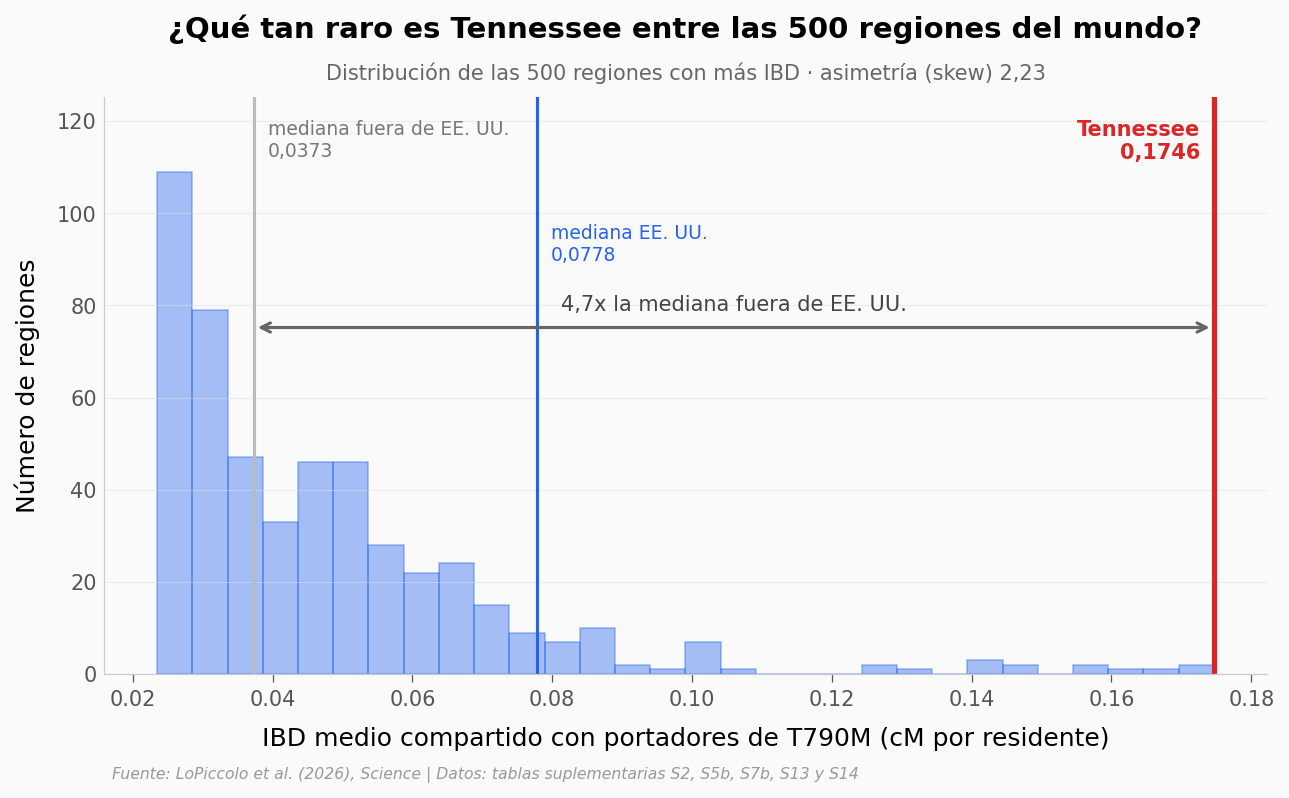

Tennessee está en el percentil 99,8 de las 500 regiones; mediana global 0,0416 cM (IQR 0,0294–0,0566)
Condados: los 500 con más IBD están en solo 19 estados; 32 de los 50 primeros están en el sureste apalache
Condado con más IBD: Dade (Georgia), 0,3068 cM · mediana de condados 0,1832 (IQR 0,1724–0,2007)
Sin un solo condado de California, Nueva York, Pensilvania, Ohio o Illinois: True


In [5]:
fig, ax = plt.subplots(figsize=(10, 5))
data = reg.ibd_medio_cm
n, bins, patches = ax.hist(data, bins=30, color=COLOR_DATOS, alpha=0.4, edgecolor=COLOR_DATOS, linewidth=0.8)
y_max = n.max() * 1.15
ax.set_ylim(0, y_max)

med_fuera = fuera.ibd_medio_cm.median()
med_us = us.ibd_medio_cm.median()
tn = us.loc[us.estado == 'Tennessee', 'ibd_medio_cm'].iloc[0]
ax.axvline(med_fuera, color=COLOR_CONTEXTO, lw=1.5)
ax.axvline(med_us, color=COLOR_DATOS, lw=1.5)
ax.axvline(tn, color=COLOR_ALERTA, lw=2.5)
ax.text(med_fuera + 0.002, y_max * 0.96, f'mediana fuera de EE. UU.\n{es(med_fuera, 4)}', fontsize=9, color='#777777', va='top')
ax.text(med_us + 0.002, y_max * 0.78, f'mediana EE. UU.\n{es(med_us, 4)}', fontsize=9, color=COLOR_DATOS, va='top')
ax.text(tn - 0.002, y_max * 0.96, f'Tennessee\n{es(tn, 4)}', fontsize=10, fontweight='bold', color=COLOR_ALERTA, ha='right', va='top')
ax.annotate('', xy=(tn, y_max * 0.6), xytext=(med_fuera, y_max * 0.6),
            arrowprops=dict(arrowstyle='<->', color='#666666', lw=1.5))
ax.text((tn + med_fuera) / 2, y_max * 0.63, f'{es(tn / med_fuera, 1)}x la mediana fuera de EE. UU.', ha='center', fontsize=10, color='#444444')
ax.set_xlabel('IBD medio compartido con portadores de T790M (cM por residente)')
ax.set_ylabel('Número de regiones')
ax.set_title('¿Qué tan raro es Tennessee entre las 500 regiones del mundo?', fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, f'Distribución de las {len(reg)} regiones con más IBD · asimetría (skew) {es(stats.skew(data), 2)}',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/histograma_ibd.png', dpi=200, bbox_inches='tight')
plt.show()

conA = con[con.grupo_ancestria == GRUPO_ANCESTRIA].sort_values('ibd_medio_cm', ascending=False).reset_index(drop=True)
top50 = conA.head(50)
print(f'Tennessee está en el percentil {es(100 * (data < tn).mean(), 1)} de las {len(reg)} regiones; '
      f'mediana global {es(data.median(), 4)} cM (IQR {es(data.quantile(.25), 4)}–{es(data.quantile(.75), 4)})')
print(f'Condados: los {len(conA)} con más IBD están en solo {conA.estado.nunique()} estados; '
      f'{top50.estado.isin(SURESTE_APALACHE).sum()} de los 50 primeros están en el sureste apalache')
print(f'Condado con más IBD: {conA.iloc[0].condado} ({conA.iloc[0].estado}), {es(conA.iloc[0].ibd_medio_cm, 4)} cM · '
      f'mediana de condados {es(conA.ibd_medio_cm.median(), 4)} (IQR {es(conA.ibd_medio_cm.quantile(.25), 4)}–{es(conA.ibd_medio_cm.quantile(.75), 4)})')
print('Sin un solo condado de California, Nueva York, Pensilvania, Ohio o Illinois:',
      not conA.estado.isin(['California', 'New York', 'Pennsylvania', 'Ohio', 'Illinois']).any())

Tennessee está a 4,7 veces la mediana de las regiones fuera de EE. UU., en la cola derecha de una distribución muy asimétrica (skew 2,23). A escala de condado la señal se afina: los 500 condados con más IBD caben en 19 estados, 32 de los 50 primeros están en el sureste apalache, y no hay ni uno de California, Nueva York, Pensilvania, Ohio o Illinois. El paper lo atribuye a un efecto fundador — un antepasado común hace 200 a 225 años cuya descendencia se quedó en la región. Los datos abiertos no permiten recomputar esa fecha; lo que sí muestran es la concentración.

### Lo que los datos soportan

| Afirmación | ¿Soportada? | Detalle |
|------------|-------------|---------|
| Los portadores de T790M tienen unas 25 veces más probabilidades de cáncer de pulmón (OR 25,18; IC 95% 13,50–46,78) | ✅ | Transcrito de la tabla S2 del paper (cohorte completa, ajustado por tabaquismo; p = 1,9×10⁻²⁴). No recomputado: los datos individuales de 23andMe no son públicos |
| El 3,784% de los portadores tenía cáncer de pulmón frente al 0,325% de los no portadores | ✅ | Recomputado desde los conteos de celda (14 de 370 vs 8.090 de 2.488.751). Riesgo relativo crudo 11,6 y OR crudo 12,1, coherentes con el 19,04 ajustado del paper para esa subcohorte |
| La asociación es varias veces mayor en nunca fumadores que en fumadores (OR 61,70 frente a 10,59) | ⚠️ | El cociente es 5,8, pero los intervalos (28,90–131,73 y 2,39–47,08) se solapan. "Varias veces" es el techo de lo afirmable; un factor exacto no |
| En las 41 familias, 68 de 147 portadores genotipados tenían cáncer de pulmón y 0 de 98 no portadores | ✅ | Fisher p = 3,2×10⁻¹⁹, pero con sesgo de reclutamiento: los porcentajes (46,3% frente a 0,0%) no son tasas poblacionales. 83 de los 151 casos de cáncer no están genotipados |
| Entre hermanos discordantes, la variante acompaña al cáncer en 24 pares y en 0 va al revés (p = 1,19×10⁻⁷) | ✅ | Réplica exacta del código de los autores: 15 hermandades, 45 hermanos. Sin probandos: 10 frente a 0 (p = 1,95×10⁻³) |
| La variante se transmitió a los 29 hijos afectados de padres portadores (29 de 29, p = 3,73×10⁻⁹) | ⚠️ | 13 de esos 29 hijos son probandos, aunque el material suplementario dice que se excluyen. Sin ellos: 16 de 16, p = 3,05×10⁻⁵. Misma dirección, mucha menos certeza |
| Las 51 regiones de EE. UU. comparten el doble de genoma con los portadores que las 449 del resto del mundo (mediana 0,0778 frente a 0,0373 cM) | ✅ | Mann-Whitney p = 5,95×10⁻²⁰ sobre las 500 regiones con más IBD (grupo de ancestría "All"). Es un ranking truncado: fuera de este top 500 no sabemos nada |
| Los 9 estados del sureste apalache tienen una mediana de IBD 2,2 veces mayor que los otros 42 (0,1554 frente a 0,0701 cM) | ✅ | Mann-Whitney p = 2,0×10⁻⁵. Los 9 estados son una selección nuestra (Tennessee, Kentucky, Virginia Occidental, Virginia, Carolina del Norte, Georgia, Alabama, Misisipi, Carolina del Sur), no una definición del paper |
| El efecto fundador ocurrió hace 200 a 225 años | ✅ | Dato del paper (análisis de TMRCA en el cuerpo del artículo). Los archivos abiertos no lo permiten recomputar |

> **Limitaciones:** (1) Diseño observacional — todo lo anterior es asociación, no causa. (2) Los OR de 23andMe vienen transcritos de las tablas del paper; el dato individual está cerrado. (3) La prevalencia (1 de cada 15.850 / 8.920 / 2.078) la declara el paper y no se deriva de los conteos abiertos, que usan otro denominador. (4) Las 41 familias INHERIT se reclutaron por tener cáncer y variante; solo los tests dentro de familia (hermanos, transmisión) esquivan ese sesgo, y en el TDT la versión con y sin probandos difiere en cuatro órdenes de magnitud de p. (5) El IBD es "cM medios por residente": ordena regiones pero no mide parentesco absoluto, y regiones con pocos participantes son ruidosas (el top 10 de condados incluye Jackson, Colorado, y King, Texas, condados minúsculos). (6) Las tablas S13 y S14 son listas top 500 — la distribución que ves está truncada por arriba. (7) Los grupos de ancestría de 23andMe (*Southern Colonial*, *British Isles*…) son etiquetas de la empresa, no categorías genéticas estándar.

## Ahora tú

1. **¿Cómo cambia el ranking de regiones si miras solo la ancestría "British Isles" en vez de "All"?** Cambia `GRUPO_ANCESTRIA = 'British Isles'` en la celda de configuración y vuelve a correr el ranking. Pista: `ibd.grupo_ancestria.unique()` te da los siete grupos.

2. **¿Qué pasa con la comparación sureste vs resto si añades Arkansas (5 condados en el top 50) a la lista?** Edita `SURESTE_APALACHE` y mira cómo se mueven las medianas. ¿Y si quitas Virginia Occidental, que está en la cola del grupo?

3. **¿Cuántas hermandades se pierden si exiges que ambos padres estén genotipados, no solo presentes en el pedigrí?** Modifica la condición de `mcnemar()` para usar `gmap.get((familia, padre_id))` en vez de `padre_id != 0` y compara B y C.

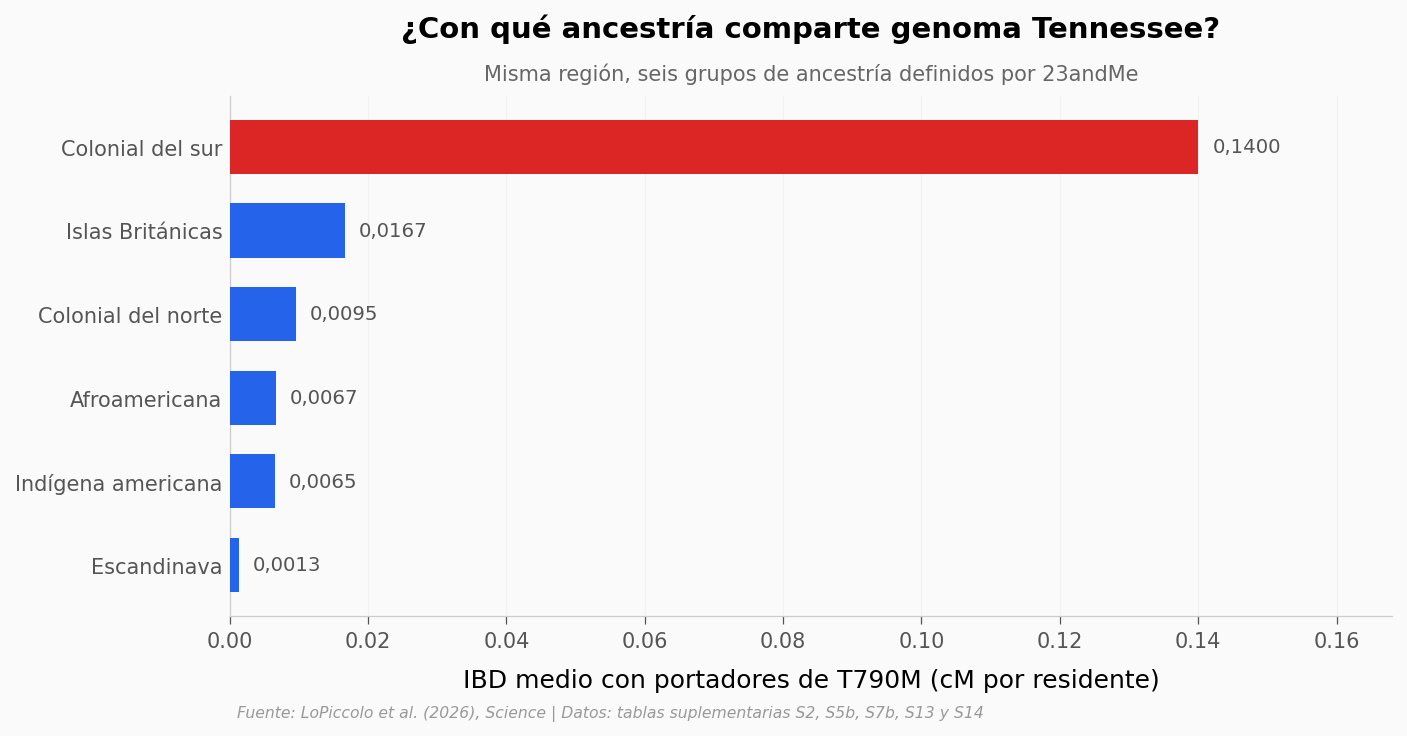

Tennessee: Colonial del sur 0,1400 cM vs Islas Británicas 0,0167 cM → 8,4x
El parentesco con los portadores no viene de los recién llegados de Gran Bretaña, sino de los colonos que llevan siglos en el sur.
Prueba con ESTADO = "Mississippi" — ¿qué grupo lidera ahí?


In [6]:
# --- EXPERIMENTA AQUÍ ---
# La misma region, vista por grupo de ancestria: ¿con quien comparte genoma Tennessee?
ESTADO = 'Tennessee'
tnA = ibd[ibd.estado == ESTADO].set_index('grupo_ancestria').ibd_medio_cm.drop('All').sort_values(ascending=False)
ETIQ_ANC = {'Southern Colonial': 'Colonial del sur', 'Northern Colonial': 'Colonial del norte',
            'British Isles': 'Islas Británicas', 'African American': 'Afroamericana',
            'Indigenous American': 'Indígena americana', 'Scandinavian American': 'Escandinava'}

fig, ax = plt.subplots(figsize=(10, 4.5))
ys = np.arange(len(tnA))[::-1]
cols = [COLOR_ALERTA if i == 0 else COLOR_DATOS for i in range(len(tnA))]
ax.barh(ys, tnA.values, color=cols, height=0.65, zorder=4)
for y, v in zip(ys, tnA.values):
    ax.text(v + 0.002, y, es(v, 4), va='center', fontsize=9.5, color='#555555')
ax.set_yticks(ys)
ax.set_yticklabels([ETIQ_ANC.get(g, g) for g in tnA.index], fontsize=10)
ax.set_xlim(0, tnA.max() * 1.2)
ax.set_xlabel('IBD medio con portadores de T790M (cM por residente)')
ax.grid(axis='y', visible=False)
ax.grid(axis='x', alpha=0.3)
ax.set_title(f'¿Con qué ancestría comparte genoma {ESTADO}?', fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Misma región, seis grupos de ancestría definidos por 23andMe', transform=ax.transAxes,
        fontsize=10, color='#666666', ha='center')
fig.text(0.13, -0.04, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/tennessee_ancestria.png', dpi=200, bbox_inches='tight')
plt.show()

print(f'{ESTADO}: {ETIQ_ANC[tnA.index[0]]} {es(tnA.iloc[0], 4)} cM vs Islas Británicas {es(tnA["British Isles"], 4)} cM '
      f'→ {es(tnA.iloc[0] / tnA["British Isles"], 1)}x')
print('El parentesco con los portadores no viene de los recién llegados de Gran Bretaña, sino de los colonos que llevan siglos en el sur.')
print('Prueba con ESTADO = "Mississippi" — ¿qué grupo lidera ahí?')

## Créditos

- **Paper:** LoPiccolo, J. et al. (2026). *Germline EGFR T790M mutation and lung cancer risk*. Science. DOI: [10.1126/science.aec0473](https://doi.org/10.1126/science.aec0473). Paywall; tablas suplementarias abiertas.
- **Datos:** tablas S2, S5b, S7b, S13 y S14 del material suplementario, convertidas a CSV. El recodeo del genotipo (`T790M_status`) y los valores de referencia de la réplica salen del [repositorio de los autores](https://github.com/sashagusev/egfr-t790m). Los datos genómicos crudos de INHERIT están bajo acceso controlado (dbGaP phs004412.v1.p1) y no se usan.
- **Código:** [Ciencia a Mordiscos / lab](https://github.com/Ciencia-a-Mordiscos/lab/tree/main/papers/2026-09-18-egfr-t790m-cancer-pulmon-apalaches) — MIT.

## Fuentes

**Paper**: [Germline EGFR T790M mutation and lung cancer risk](https://doi.org/10.1126/science.aec0473)  
*Science, 2026-09-17 · paywall*

**Supplementary Material**: [Supplementary Materials for Germline EGFR T790M mutation and lung cancer risk](https://www.science.org/doi/suppl/10.1126/science.aec0473/suppl_file/science.aec0473_sm.pdf)  
*Science, 2026-09-17*

**Supplementary Material**: [Tables S5b, S6b, S7b, S13, S14 y S20 (datos suplementarios en Excel)](https://www.science.org/doi/suppl/10.1126/science.aec0473/suppl_file/science.aec0473_tables_s5b_s6b_s7b_s13_s14_s20.zip)  
*Science, 2026-09-17*

**Referencias citadas**: [sashagusev/egfr-t790m — codigo de reproduccion y analisis within-family](https://github.com/sashagusev/egfr-t790m)

*32 afirmaciones del notebook verificadas contra estas fuentes*